In [9]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.datasets import CIFAR10
import pickle

# Data Import, Visualize, Normalize

In [11]:
train_dataset = CIFAR10(root='../../Datasets/', train=True, download=True)
test_dataset = CIFAR10(root='../../Datasets/', train=False, download=True)

/Users/raghu-2264/Raghu/Personal Works/learnings/llm-finetuning-journey/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [60]:
x_train =  torch.tensor(train_dataset.data) #train_dataset.data has numpy array format
y_train = torch.tensor(train_dataset.targets)

n = x_train.shape[0]
classes = train_dataset.classes
num_classes = len(classes)

x_test = torch.tensor(test_dataset.data)
y_test = torch.tensor(test_dataset.targets)

In [61]:
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [62]:
x_train.shape, x_test.shape

(torch.Size([50000, 32, 32, 3]), torch.Size([10000, 32, 32, 3]))

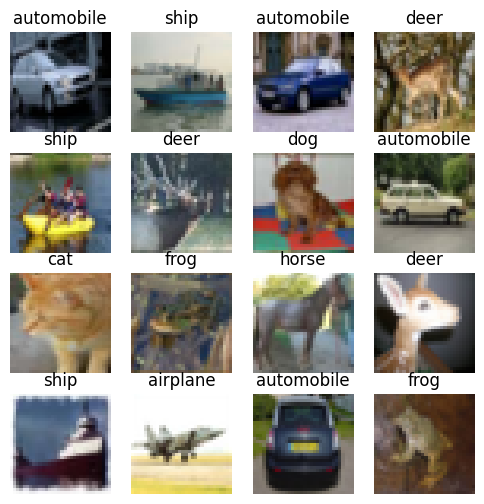

In [63]:
ti = 4
total_images = ti ** 2
indices = torch.randint(0, n, size=(total_images,))
plt.figure(figsize=(6,6))
for i, idx in enumerate(indices):
    plt.subplot(ti, ti ,i+1)
    plt.imshow(x_train[idx])
    plt.title(classes[y_train[idx]])
    plt.axis('off')
plt.show()

In [64]:
x_train[0].flatten()[:50]

tensor([ 59,  62,  63,  43,  46,  45,  50,  48,  43,  68,  54,  42,  98,  73,
         52, 119,  91,  63, 139, 107,  75, 145, 110,  80, 149, 117,  89, 149,
        120,  93, 131, 103,  77, 125,  99,  76, 142, 115,  91, 144, 112,  86,
        137, 105,  79, 129,  97,  71, 137, 106], dtype=torch.uint8)

In [72]:
x_train_norm = x_train/255.0
x_test_norm = x_test/255.0

#print(f"{x_train[0].shape=},\n{x_train_norm.min().item()=},\n{x_train_norm.max().item()=}\n\n")
#print(f"Before normalization: \n{x_train_norm.mean(dim=[0,1,2])=},\n{x_train_norm.std(dim=[0,1,2])=}\n\n")

x_train_norm_mean = x_train_norm.mean(dim=[0,1,2], keepdim=True) #across all the data in a channel
x_train_norm_std = x_train_norm.std(dim=[0,1,2], keepdim=True) + 1e-9
#print(f"Mean and std shape: {x_train_norm_mean.shape}")
x_train_norm = (x_train_norm - x_train_norm_mean)/x_train_norm_std
#print(f"After normalization: \n{x_train_norm.mean(dim=[0,1,2])=},\n{x_train_norm.std(dim=[0,1,2])=}\n\n")


x_test_norm = (x_test_norm - x_train_norm_mean)/x_train_norm_std
#print(f"Test data after normalization with mean & std of training data: ")
#print(f"{x_test_norm.mean(dim=[0,1,2])=},\n{x_test_norm.std(dim=[0,1,2])=}")

x_train_norm = x_train_norm.permute(0,3,1,2) #to match the input accepted by the pytorch convolution
x_test_norm = x_test_norm.permute(0,3,1,2)

print(f"{x_train_norm.shape=}")

y_train_oh = F.one_hot(y_train, num_classes=num_classes) * 1.0
y_test_oh = F.one_hot(y_test, num_classes=num_classes) * 1.0

x_train_norm.shape=torch.Size([50000, 3, 32, 32])


# Resnet50 without Residual Connections

![](https://i.sstatic.net/XTo6Q.png)
<caption><center> <u> <font color='purple'> <b>Figure 5</b> </u><font color='purple'>  : <b>ResNet-50 model</b> </center></caption>

The details of this ResNet-50 model are:
- Zero-padding pads the input with a pad of (3,3)
- Stage 1:
    - The 2D Convolution has 64 filters of shape (7,7) and uses a stride of (2,2). 
    - BatchNorm is applied to the 'channels' axis of the input.
    - MaxPooling uses a (3,3) window and a (2,2) stride.
- Stage 2:
    - The convolutional block uses three sets of filters of size [64,64,256], "f" is 3, and "s" is 1.
    - The 2 identity blocks use three sets of filters of size [64,64,256], and "f" is 3.
- Stage 3:
    - The convolutional block uses three sets of filters of size [128,128,512], "f" is 3 and "s" is 2.
    - The 3 identity blocks use three sets of filters of size [128,128,512] and "f" is 3.
- Stage 4:
    - The convolutional block uses three sets of filters of size [256, 256, 1024], "f" is 3 and "s" is 2.
    - The 5 identity blocks use three sets of filters of size [256, 256, 1024] and "f" is 3.
- Stage 5:
    - The convolutional block uses three sets of filters of size [512, 512, 2048], "f" is 3 and "s" is 2.
    - The 2 identity blocks use three sets of filters of size [512, 512, 2048] and "f" is 3.
- The 2D Average Pooling uses a window of shape (2,2).
- The 'flatten' layer doesn't have any hyperparameters.
- The Fully Connected (Dense) layer reduces its input to the number of classes using a softmax activation.

In [136]:
class init_block(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=2) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.layers(x)
        return x
    

In [147]:
class conv_block(nn.Module):
    def __init__(self, in_channels, channels, filter, stride=2) -> None:
        super().__init__()
        C1, C2, C3 = channels
        self.layer1 = nn.Sequential(
            
            #First component of main path
            nn.Conv2d(in_channels, C1, kernel_size=1, stride=stride, padding='valid'),
            nn.BatchNorm2d(C1),
            nn.ReLU(),
            
            #Second component of main path
            nn.Conv2d(C1, C2, kernel_size=filter, stride=1, padding='same'),
            nn.BatchNorm2d(C2),
            nn.ReLU(),
            
            #Third component of main path
            nn.Conv2d(C2, C3, kernel_size=1, stride=1, padding='valid'),
            nn.BatchNorm2d(C3)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels, C3, kernel_size=1, stride=stride, padding="valid"),
            nn.BatchNorm2d(C3)
        )

    def forward(self, x):
        #print(f"Input Shape: {x.shape}")
        x_main = self.layer1(x)
        #print(f"After processing main line: {x_main.shape}")
        
        x_shortcut = self.layer2(x)
        #print(f"After processing second line: {x_shortcut.shape}")
        
        x = x_shortcut + x_main
        x = nn.ReLU()(x)
        
        return x
        

In [148]:
class identity_block(nn.Module):
    def __init__(self, in_channels, channels, filter) -> None:
        super().__init__()

        C1, C2, C3 = channels
        self.layer1 = nn.Sequential(
            
            #First component of main path
            nn.Conv2d(in_channels, C1, kernel_size=1, stride=1, padding='valid'),
            nn.BatchNorm2d(C1),
            nn.ReLU(),
            
            #Second component of main path
            nn.Conv2d(C1, C2, kernel_size=filter, stride=1, padding='same'),
            nn.BatchNorm2d(C2),
            nn.ReLU(),
            
            #Third component of main path
            nn.Conv2d(C2, C3, kernel_size=1, stride=1, padding='valid'),
            nn.BatchNorm2d(C3)
        )
        
    def forward(self, x):
        #print(f"Input Shape: {x.shape}")
        x_main = self.layer1(x)
        #print(f"After processing main line: {x_main.shape}")
        
        x = x + x_main
        x = nn.ReLU()(x)
        
        return x

In [151]:
layers = [
    init_block(in_channels = 3, out_channels=64, kernel_size=3, stride=1),
    conv_block(in_channels = 64, channels=[64, 64, 256], filter=3),
    identity_block(in_channels=256, channels=[64, 64, 256], filter=3),
    nn.Flatten(),
    nn.Linear(256*8*8, num_classes)
]

model = nn.Sequential(*layers)
parameters = sum([p.numel() for p in model.parameters()])
print(f"Total Parameters: {parameters}")

with torch.no_grad():
    print(model(x_train_norm[:2]).shape)

Total Parameters: 312202
torch.Size([2, 10])


In [152]:
epochs = 1
losses = []
optimizer = torch.optim.Adam(model.parameters(), lr = 0.005)

for epoch in range(epochs):
    
    logits = model(x_train_norm)
    loss = F.cross_entropy(logits, y_train_oh)
    losses.append(loss.item())

    print(loss.item())
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

2.494943618774414


In [153]:
with torch.no_grad():
    n_train = x_train.shape[0]
    logits = model(x_train_norm)
    y_train_pred = F.softmax(logits, dim=1).argmax(dim=1)
    print(y_train_pred)
    misses = (y_train_pred != y_train).sum().item()
    print(f"Train Accuracy: {(n_train-misses)/n_train*100:.2f}%")
    
    n_test = x_train.shape[0]
    logits = model(x_test_norm)
    y_test_pred = F.softmax(logits, dim=1).argmax(dim=1)
    misses = (y_test_pred != y_test).sum().item()
    print(f"Test Accuracy: {(n_test-misses)/n_test*100:.2f}%")
    

tensor([3, 1, 1,  ..., 1, 1, 1])
Train Accuracy: 12.62%
Test Accuracy: 82.50%


frog


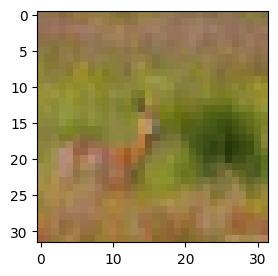

In [173]:
# Predict
idx = torch.randint(0, n_train, size=(1,))
x = x_train_norm[idx]
with torch.no_grad():
    model.eval()
    logits = model(x)
    y_train_pred = F.softmax(logits, dim=1).argmax(dim=1)
    print(classes[y_train_pred.item()])
    
plt.figure(figsize=(3,3))
plt.imshow(x_train[idx].squeeze(dim=0))
plt.show()

In [177]:
for p in model.parameters():
    print(p.grad.max(), p.grad.min())

tensor(0.0375) tensor(-0.0363)
tensor(6.2380e-08) tensor(-8.3544e-08)
tensor(0.0116) tensor(-0.0113)
tensor(0.0078) tensor(-0.0107)
tensor(0.0267) tensor(-0.0198)
tensor(4.0702e-08) tensor(-3.7090e-08)
tensor(0.0055) tensor(-0.0074)
tensor(0.0043) tensor(-0.0052)
tensor(0.0272) tensor(-0.0223)
tensor(3.1998e-08) tensor(-3.2072e-08)
tensor(0.0064) tensor(-0.0081)
tensor(0.0043) tensor(-0.0055)
tensor(0.0143) tensor(-0.0112)
tensor(1.9090e-08) tensor(-1.5375e-08)
tensor(0.0055) tensor(-0.0055)
tensor(0.0055) tensor(-0.0045)
tensor(0.0132) tensor(-0.0143)
tensor(2.3871e-08) tensor(-1.9035e-08)
tensor(0.0062) tensor(-0.0035)
tensor(0.0055) tensor(-0.0045)
tensor(0.0218) tensor(-0.0191)
tensor(2.0730e-08) tensor(-1.6150e-08)
tensor(0.0053) tensor(-0.0072)
tensor(0.0056) tensor(-0.0071)
tensor(0.0275) tensor(-0.0295)
tensor(2.5721e-08) tensor(-1.5750e-08)
tensor(0.0057) tensor(-0.0062)
tensor(0.0051) tensor(-0.0069)
tensor(0.0121) tensor(-0.0103)
tensor(1.3814e-08) tensor(-1.6473e-08)
tensor